# 04 · Modelo 1X2: ¿qué decide un partido?

**Pregunta central:** ¿qué decide un partido de LaLiga: la fuerza, la forma, el estilo o el azar?

**Decisiones de esta fase**

| Decisión | Elección | Motivo |
|---|---|---|
| Validación | Progresiva (*walk-forward*), ventana creciente desde 2014/15: 5 pliegues que validan 2019/20 a 2023/24 | Cada temporada se predice solo con las anteriores, como en la realidad |
| Test | **2024/25 y 2025/26 (760 partidos), intactas hasta el final** | Nota final con datos nunca usados para decidir nada |
| Métricas | **RPS** (principal), *log-loss* (secundaria), acierto (para comunicar), calibración (diagnóstico) | El RPS respeta el orden 1 > X > 2 y es el estándar en fútbol |
| Referencias | 0: uniforme · 1: frecuencias históricas · 2: solo Elo (mismo modelo, una variable) · "siempre local" para el acierto | El listón, al no usar cuotas |
| Fuerza y forma | Diferencias local − visitante: `elo_dif`, `forma_puntos_dif`, `forma_xg_dif_dif` | Pocas variables; lo que importa es quién está mejor |
| Exclusiones | Partidos con un ascendido en sus 5 primeros partidos, sin 5 partidos de forma en xG (calentamiento de 2014/15) o sin 10 partidos en la ventana de estilo | Sin inventar valores. **Todos los modelos se evalúan sobre los mismos partidos** |
| Estilo | 6 coordenadas por equipo con los **19 partidos anteriores** (mínimo 10), estandarizadas con la **referencia de la temporada anterior** y descontada la calidad con una regresión **ajustada solo con el entrenamiento de cada pliegue** | Sin fuga de información |
| Choque de estilos | 2 interacciones fijadas de antemano: presión local × posesión visitante (I1) y posesión local × presión visitante (I2) | Hipótesis futbolística previa; probar todas sería sobreajuste |
| Pregunta central | Bloques **añadidos en orden** (historia) y **quitados uno a uno** del modelo completo (lo que cada bloque aporta en exclusiva) | El orden influye en lo que se atribuye a cada bloque |
| ¿Mejora real? | *Bootstrap* emparejado por partido (IC 95 %) + consistencia entre los 5 pliegues | Las diferencias son pequeñas; hay que separarlas del ruido |
| Azar | "Techo informativo": modelo con el xG **del propio partido** (información posterior, **no es una predicción**) | Separa lo que se sabe antes del partido, lo que se decide en el juego y el azar |
| Modelo | Regresión logística **ordinal** con regularización *ridge* (intensidad elegida dentro del entrenamiento); *gradient boosting* como comprobación | Respeta el orden de los resultados y es interpretable |


## 0. Preparación

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"

con = duckdb.connect()
for tabla in ("partidos", "partidos_equipo", "forma_elo", "estilos_equipo_temporada"):
    con.sql(f"CREATE VIEW {tabla} AS SELECT * FROM read_csv('{(PROCESSED / f'{tabla}.csv').as_posix()}')")

SERIE, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
TEMPORADAS_VALIDACION = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24"]
TEMPORADAS_TEST = ["2024-25", "2025-26"]

## 1. Ventana de estilo previa a cada partido

Para cada equipo y partido sumamos las piezas de sus **19 partidos anteriores** de la misma etapa en Primera (`ROWS BETWEEN 19 PRECEDING AND 1 PRECEDING`: el partido actual nunca entra). Solo cuentan partidos con datos de Understat. Con las sumas calculamos los ratios como cociente de sumas, igual que en la fase 3.

`n_estilo` guarda cuántos partidos entran en la ventana (se exigirá un mínimo de 10).

In [2]:
con.sql("""
CREATE OR REPLACE TABLE ventana_estilo AS
WITH base AS (
    SELECT pe.id_partido, pe.equipo, pe.temporada, pe.fecha, fe.etapa,
           pe.xg_favor IS NOT NULL AS con_understat,
           pe.ppda_pases, pe.ppda_acciones, pe.ppda_pases_rival, pe.ppda_acciones_rival,
           pe.pases_profundos_favor, pe.xg_favor, pe.tiros_favor, pe.xg_contra, pe.tiros_contra,
           CASE WHEN pe.xg_favor IS NOT NULL THEN pe.faltas_cometidas END AS faltas,
           CASE WHEN pe.xg_favor IS NOT NULL THEN fe.elo_antes END        AS elo_con_understat
    FROM partidos_equipo pe
    JOIN forma_elo fe USING (id_partido, equipo)
)
SELECT id_partido, equipo, temporada,
       count(ppda_pases)                                         OVER w AS n_estilo,
       sum(ppda_pases) OVER w / sum(ppda_acciones) OVER w                AS ppda,
       sum(ppda_pases_rival) OVER w / sum(ppda_acciones_rival) OVER w    AS ppda_rival,
       avg(pases_profundos_favor)                                OVER w AS profundos_pp,
       sum(xg_favor) OVER w / sum(tiros_favor) OVER w                    AS xg_por_tiro,
       sum(xg_contra) OVER w / sum(tiros_contra) OVER w                  AS xg_por_tiro_contra,
       avg(faltas)                                               OVER w AS faltas_pp,
       avg(elo_con_understat)                                    OVER w AS elo_medio
FROM base
WINDOW w AS (PARTITION BY equipo, etapa ORDER BY fecha, id_partido
             ROWS BETWEEN 19 PRECEDING AND 1 PRECEDING)
""")
con.sql("SELECT * FROM ventana_estilo WHERE equipo = 'Getafe' AND temporada = '2019-20' LIMIT 3").df()

,id_partido,equipo,temporada,n_estilo,ppda,ppda_rival,profundos_pp,xg_por_tiro,xg_por_tiro_contra,faltas_pp,elo_medio
0,2668,Getafe,2019-20,19,7.639794,5.657431,4.894737,0.129601,0.125515,16.052632,1535.635166
1,2674,Getafe,2019-20,19,7.952548,5.845361,4.789474,0.124579,0.139121,16.315789,1537.277431
2,2683,Getafe,2019-20,19,7.864043,5.746154,4.842105,0.124519,0.135502,15.736842,1537.839931


## 2. Estandarización con la referencia de la temporada anterior

Cada valor de la ventana se estandariza con la **media y la desviación típica de la liga en la temporada anterior** (los 20 equipos-temporada de la fase 3), que ya se conocen al empezar la temporada.

**Excepción documentada:** 2014/15 no tiene temporada anterior con datos de Understat, así que usa su propia referencia. 2014/15 solo aparece en **entrenamiento**, nunca en validación ni en test, y la diferencia entre la referencia de un año y la del siguiente es pequeña (la tendencia de la liga).

In [3]:
VARIABLES_ESTILO = ["ppda", "ppda_rival", "profundos_pp", "xg_por_tiro", "xg_por_tiro_contra", "faltas_pp"]
COLUMNAS_Z = [*VARIABLES_ESTILO, "elo_medio"]

temporadas = sorted(con.sql("SELECT DISTINCT temporada FROM estilos_equipo_temporada").df().temporada)
estadisticas = con.sql("SELECT * FROM estilos_equipo_temporada").df().groupby("temporada")[COLUMNAS_Z].agg(["mean", "std"])
referencia = {t: (temporadas[i - 1] if i > 0 else t) for i, t in enumerate(temporadas)}   # 2014-15 -> sí misma
print("Referencia usada por temporada:", referencia)

ventana = con.sql("SELECT * FROM ventana_estilo WHERE temporada >= '2014-15'").df()
ref = estadisticas.loc[ventana.temporada.map(referencia)].reset_index(drop=True)
for col in COLUMNAS_Z:
    ventana[f"z_{col}"] = (ventana[col] - ref[(col, "mean")].values) / ref[(col, "std")].values
ventana[[f"z_{c}" for c in COLUMNAS_Z]].describe().loc[["mean", "std"]].round(2)

Referencia usada por temporada: {'2014-15': '2014-15', '2015-16': '2014-15', '2016-17': '2015-16', '2017-18': '2016-17', '2018-19': '2017-18', '2019-20': '2018-19', '2020-21': '2019-20', '2021-22': '2020-21', '2022-23': '2021-22', '2023-24': '2022-23', '2024-25': '2023-24', '2025-26': '2024-25'}


,z_ppda,z_ppda_rival,z_profundos_pp,z_xg_por_tiro,z_xg_por_tiro_contra,z_faltas_pp,z_elo_medio
mean,0.18,0.10,0.01,-0.02,-0.10,-0.04,0.01
std,1.25,1.09,1.02,1.22,1.44,1.14,0.98


## 3. Tabla del modelo: un partido por fila, visto desde el local

Unimos, para el local y el visitante: Elo antes del partido, forma, periodo de ascenso y ventana de estilo. El **objetivo** es el resultado ordenado: 0 = gana el visitante, 1 = empate, 2 = gana el local.

**Exclusiones** (se aplican igual a todos los modelos):
- algún equipo en sus 5 primeros partidos tras ascender;
- algún equipo sin 5 partidos con xG en su forma (calentamiento de 2014/15);
- algún equipo con menos de 10 partidos en su ventana de estilo.

In [4]:
fe = con.sql("SELECT * FROM forma_elo").df()
p = con.sql("SELECT id_partido, temporada, fecha, local, visitante, resultado FROM partidos WHERE temporada >= '2014-15'").df()

def lado(df, prefijo):
    return df.rename(columns={c: f"{c}_{prefijo}" for c in df.columns if c not in ("id_partido",)})

cols_fe = ["id_partido", "equipo", "elo_antes", "periodo_ascenso", "forma_puntos", "n_forma", "forma_xg_dif", "n_forma_xg"]
cols_ve = ["id_partido", "equipo", "n_estilo", *[f"z_{c}" for c in COLUMNAS_Z]]
for prefijo, columna_equipo in (("local", "local"), ("visit", "visitante")):
    p = p.merge(lado(fe[cols_fe], prefijo), left_on=["id_partido", columna_equipo],
                right_on=["id_partido", f"equipo_{prefijo}"])
    p = p.merge(lado(ventana[cols_ve], prefijo), left_on=["id_partido", columna_equipo],
                right_on=["id_partido", f"equipo_{prefijo}"])

p["y"] = p.resultado.map({"2": 0, "X": 1, "1": 2})
p["elo_dif"] = p.elo_antes_local - p.elo_antes_visit
p["forma_puntos_dif"] = p.forma_puntos_local - p.forma_puntos_visit
p["forma_xg_dif_dif"] = p.forma_xg_dif_local - p.forma_xg_dif_visit

motivos = pd.DataFrame({
    "ascendido en sus 5 primeros partidos": p.periodo_ascenso_local | p.periodo_ascenso_visit,
    "sin 5 partidos de forma en xG": (p.n_forma_xg_local < 5) | (p.n_forma_xg_visit < 5),
    "menos de 10 partidos en la ventana de estilo": (p.n_estilo_local < 10) | (p.n_estilo_visit < 10),
})
p["excluido"] = motivos.any(axis=1)
resumen_exclusion = pd.concat([motivos, p.excluido.rename("excluido (algún motivo)")], axis=1).groupby(p.temporada).sum()
resumen_exclusion.insert(0, "partidos", p.groupby("temporada").size())
resumen_exclusion

,partidos,ascendido en sus 5 primeros partidos,sin 5 partidos de forma en xG,menos de 10 partidos en la ventana de estilo,excluido (algún motivo)
temporada,,,,,
2014-15,380,14,50,100,100
2015-16,380,15,15,29,29
2016-17,380,15,15,30,30
2017-18,380,15,15,29,29
2018-19,380,14,14,28,28
2019-20,380,15,15,29,29
2020-21,380,13,13,28,28
2021-22,380,14,14,29,29
2022-23,380,13,13,27,27


In [5]:
# Las temporadas de test se apartan aquí y NO se usan hasta la sección final
test = p[p.temporada.isin(TEMPORADAS_TEST)].copy()
datos = p[~p.temporada.isin(TEMPORADAS_TEST) & ~p.excluido].reset_index(drop=True)
assert not datos.temporada.isin(TEMPORADAS_TEST).any()
print(f"Partidos para entrenar/validar: {len(datos)} · apartados para test: {len(test)} (sin mirar)")

Partidos para entrenar/validar: 3442 · apartados para test: 760 (sin mirar)


## 4. Coordenadas de estilo sin fuga: descontar la calidad dentro de cada pliegue

Para cada variable de estilo, la regresión que descuenta la calidad (`z_variable = a + b · z_elo`) se ajusta **solo con los partidos de entrenamiento del pliegue** y se aplica tal cual a los de validación. El residuo se reescala con la desviación típica del entrenamiento (como en la fase 3, todas las dimensiones pesan igual).

Se renombran para leerlas de forma natural: **presión** = −PPDA (alto = presiona más) y **posesión** = PPDA del rival (alto = tiene el balón).

In [6]:
NOMBRES_COORD = {"ppda": "presion", "ppda_rival": "posesion", "profundos_pp": "profundos",
                 "xg_por_tiro": "xg_por_tiro", "xg_por_tiro_contra": "xg_por_tiro_contra", "faltas_pp": "faltas"}
SIGNO = {"ppda": -1}                                   # presión = −PPDA


def coordenadas_estilo(entreno, evaluacion):
    """Devuelve copias con las 12 coordenadas de estilo y las 2 interacciones, ajustando todo con `entreno`."""
    entreno, evaluacion = entreno.copy(), evaluacion.copy()
    # la regresión usa los dos lados (local y visitante) del entrenamiento como observaciones
    for v in VARIABLES_ESTILO:
        x = np.concatenate([entreno.z_elo_medio_local, entreno.z_elo_medio_visit])
        y = np.concatenate([entreno[f"z_{v}_local"], entreno[f"z_{v}_visit"]])
        b, a = np.polyfit(x, y, deg=1)
        escala = np.std(y - (a + b * x))
        for df in (entreno, evaluacion):
            for s in ("local", "visit"):
                residuo = (df[f"z_{v}_{s}"] - (a + b * df[f"z_elo_medio_{s}"])) / escala
                df[f"{NOMBRES_COORD[v]}_{s}"] = SIGNO.get(v, 1) * residuo
    for df in (entreno, evaluacion):
        df["I1_presion_local_x_posesion_visit"] = df.presion_local * df.posesion_visit
        df["I2_posesion_local_x_presion_visit"] = df.posesion_local * df.presion_visit
    return entreno, evaluacion


COORD = [f"{n}_{s}" for s in ("local", "visit") for n in NOMBRES_COORD.values()]
INTERACCIONES = ["I1_presion_local_x_posesion_visit", "I2_posesion_local_x_presion_visit"]

## 5. Pliegues y métricas

**Pliegues:** para validar la temporada *t*, se entrena con todas las temporadas desde 2014/15 hasta *t − 1*.

**RPS** para tres resultados ordenados (local, empate, visitante), con probabilidades acumuladas $P_1 = p_{local}$, $P_2 = p_{local} + p_{empate}$ y lo mismo para el resultado real $O$:

$$\text{RPS} = \frac{1}{2}\left[(P_1 - O_1)^2 + (P_2 - O_2)^2\right]$$

Comprobamos la implementación con el ejemplo que usamos al elegir la métrica (gana el local; A = 45/35/20, B = 45/20/35): el RPS debe ser 0,171 y 0,213.

In [7]:
PLIEGUES = [(sorted(t for t in datos.temporada.unique() if t < v), v) for v in TEMPORADAS_VALIDACION]
for entreno_t, valid_t in PLIEGUES:
    print(f"valida {valid_t} · entrena {entreno_t[0]}…{entreno_t[-1]} ({len(entreno_t)} temporadas)")


def rps(prob, y):
    """prob: columnas [visitante, empate, local]; y: 0 visitante, 1 empate, 2 local."""
    real = np.eye(3)[y]
    acum_p = np.cumsum(prob[:, ::-1], axis=1)[:, :2]       # orden local → empate → visitante
    acum_o = np.cumsum(real[:, ::-1], axis=1)[:, :2]
    return 0.5 * ((acum_p - acum_o) ** 2).sum(axis=1)


def log_loss(prob, y):
    return -np.log(np.clip(prob[np.arange(len(y)), y], 1e-15, 1))


ejemplo = np.array([[0.20, 0.35, 0.45], [0.35, 0.20, 0.45]])
assert np.allclose(rps(ejemplo, np.array([2, 2])).round(3), [0.171, 0.213])
print("RPS del ejemplo:", rps(ejemplo, np.array([2, 2])).round(3))

valida 2019-20 · entrena 2014-15…2018-19 (5 temporadas)
valida 2020-21 · entrena 2014-15…2019-20 (6 temporadas)
valida 2021-22 · entrena 2014-15…2020-21 (7 temporadas)
valida 2022-23 · entrena 2014-15…2021-22 (8 temporadas)
valida 2023-24 · entrena 2014-15…2022-23 (9 temporadas)
RPS del ejemplo: [0.171 0.213]


## 6. La regresión logística ordinal

El modelo supone un **marcador latente** $\eta = X\beta$ (cuánto mejor juega el local) y dos umbrales $\theta_1 < \theta_2$:

$$P(\text{visitante}) = \sigma(\theta_1 - \eta), \quad P(\text{visitante o empate}) = \sigma(\theta_2 - \eta)$$

donde $\sigma$ es la función logística. La ventaja de local la recogen los umbrales (el modelo aprende que, con $\eta = 0$, gana más a menudo el local).

**Regularización *ridge*:** se minimiza la pérdida media más $\lambda \sum \beta^2$, con las variables estandarizadas (media 0, desviación 1 en el entrenamiento) para que la penalización trate a todas por igual. $\lambda$ se elige **dentro del entrenamiento**: se entrena con todas las temporadas menos la última y se valida en esa última; el $\lambda$ con mejor RPS se usa para reentrenar con todo el entrenamiento.

In [8]:
class RegresionOrdinal:
    def __init__(self, lam=0.0):
        self.lam = lam

    def _probs(self, Xs, beta, t1, t2):
        eta = Xs @ beta
        c1, c2 = expit(t1 - eta), expit(t2 - eta)
        return np.column_stack([c1, c2 - c1, 1 - c2])

    def fit(self, X, y):
        X = np.asarray(X, float)
        self.media, self.desv = X.mean(0), X.std(0)
        Xs = (X - self.media) / self.desv
        k = Xs.shape[1]

        def objetivo(par):
            beta, t1, t2 = par[:k], par[k], par[k] + np.exp(par[k + 1])     # garantiza t1 < t2
            prob = np.clip(self._probs(Xs, beta, t1, t2), 1e-12, 1)
            return -np.log(prob[np.arange(len(y)), y]).mean() + self.lam * (beta ** 2).sum()

        inicio = np.r_[np.zeros(k), -0.5, np.log(1.0)]
        sol = minimize(objetivo, inicio, method="L-BFGS-B")
        self.beta, self.t1, self.t2 = sol.x[:k], sol.x[k], sol.x[k] + np.exp(sol.x[k + 1])
        return self

    def predict_proba(self, X):
        Xs = (np.asarray(X, float) - self.media) / self.desv
        return self._probs(Xs, self.beta, self.t1, self.t2)


LAMBDAS = [0.0, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]


def ajustar_ordinal(entreno, variables):
    """Elige lambda con la última temporada del entrenamiento y reentrena con todo."""
    ultima = entreno.temporada.max()
    interno_e, interno_v = entreno[entreno.temporada < ultima], entreno[entreno.temporada == ultima]
    if any(v in COORD + INTERACCIONES for v in variables):                  # sin fuga también dentro
        interno_e, interno_v = coordenadas_estilo(interno_e, interno_v)
    puntuacion = {lam: rps(RegresionOrdinal(lam).fit(interno_e[variables], interno_e.y)
                           .predict_proba(interno_v[variables]), interno_v.y.to_numpy()).mean()
                  for lam in LAMBDAS}
    mejor = min(puntuacion, key=puntuacion.get)
    return RegresionOrdinal(mejor).fit(entreno[variables], entreno.y), mejor

**Comprobación de la implementación:** sin regularización y con solo `elo_dif`, nuestras probabilidades deben coincidir con las de `OrderedModel` de statsmodels (una implementación independiente).

In [9]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

entreno_prueba = datos[datos.temporada < "2019-20"]
nuestro = RegresionOrdinal(0.0).fit(entreno_prueba[["elo_dif"]], entreno_prueba.y.to_numpy())
referencia_sm = OrderedModel(entreno_prueba.y.to_numpy(), entreno_prueba[["elo_dif"]].to_numpy(), distr="logit").fit(
    method="bfgs", disp=False)
p_nuestro = nuestro.predict_proba(entreno_prueba[["elo_dif"]])
p_sm = referencia_sm.predict(entreno_prueba[["elo_dif"]].to_numpy())
print(f"Diferencia máxima de probabilidad entre implementaciones: {np.abs(p_nuestro - p_sm).max():.2e}")
assert np.abs(p_nuestro - p_sm).max() < 1e-4

Diferencia máxima de probabilidad entre implementaciones: 3.37e-06


## 7. Modelos de referencia

Todos se evalúan sobre **los mismos partidos** de validación.

| Nivel | Modelo |
|---|---|
| 0 | Uniforme (1/3 para cada resultado) |
| 1 | Frecuencias históricas del entrenamiento del pliegue (iguales para todos los partidos) |
| 2 | Ordinal con solo `elo_dif` |
| — | "Siempre gana el local" (solo para el acierto) |

In [10]:
def evaluar(prob, y):
    return {"RPS": rps(prob, y).mean(), "log_loss": log_loss(prob, y).mean(),
            "acierto": (prob.argmax(1) == y).mean()}


filas = []
predicciones = {}
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t]
    y_v = valid.y.to_numpy()

    uniforme = np.full((len(valid), 3), 1 / 3)
    frecuencias = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
    solo_elo, lam = ajustar_ordinal(entreno, ["elo_dif"])
    p_elo = solo_elo.predict_proba(valid[["elo_dif"]])

    for nombre, prob in (("0 · Uniforme", uniforme), ("1 · Frecuencias históricas", frecuencias),
                         ("2 · Solo Elo", p_elo)):
        filas.append({"modelo": nombre, "temporada": valid_t, "partidos": len(valid), **evaluar(prob, y_v)})
        predicciones.setdefault(nombre, []).append(pd.DataFrame(prob, index=valid.index))
    filas.append({"modelo": "Siempre gana el local", "temporada": valid_t, "partidos": len(valid),
                  "RPS": np.nan, "log_loss": np.nan, "acierto": (y_v == 2).mean()})

resultados_ref = pd.DataFrame(filas)
resultados_ref.pivot(index="modelo", columns="temporada", values="RPS").round(4)

temporada,2019-20,2020-21,2021-22,2022-23,2023-24
modelo,,,,,
0 · Uniforme,0.2317,0.2323,0.2289,0.2381,0.2308
1 · Frecuencias históricas,0.2230,0.2272,0.2249,0.2275,0.2251
2 · Solo Elo,0.1988,0.1941,0.1988,0.2070,0.1884
Siempre gana el local,NaN,NaN,NaN,NaN,NaN


In [11]:
# Resumen agregado sobre los 5 pliegues (media ponderada por partidos)
def agregar(df):
    pesos = df.partidos
    return pd.Series({m: np.average(df[m], weights=pesos) if df[m].notna().all() else np.nan
                      for m in ("RPS", "log_loss", "acierto")})

resumen_ref = resultados_ref.groupby("modelo").apply(agregar, include_groups=False)
resumen_ref["partidos_validacion"] = resultados_ref.groupby("modelo").partidos.sum()
resumen_ref.round(4)

,RPS,log_loss,acierto,partidos_validacion
modelo,,,,
0 · Uniforme,0.2324,1.0986,0.2844,1758
1 · Frecuencias históricas,0.2255,1.0746,0.4431,1758
2 · Solo Elo,0.1974,0.9912,0.5188,1758
Siempre gana el local,NaN,NaN,0.4431,1758


## 8. ¿Qué aporta cada bloque?

**Bloques de variables:**

| Bloque | Variables |
|---|---|
| Fuerza | `elo_dif` |
| Forma (puntos) | `forma_puntos_dif` |
| Forma (xG) | `forma_xg_dif_dif` |
| Estilo | 12 coordenadas (6 del local, 6 del visitante) |
| Choque de estilos | I1 (presión local × posesión visitante), I2 (posesión local × presión visitante) |

**Dos comparaciones** (decisión 29a):
1. **Añadir en orden:** Elo → + forma en puntos → + forma en xG → + estilo → + choque. Cuenta la historia, pero el bloque que entra antes se lleva la información que comparte con los siguientes.
2. **Quitar uno a uno** del modelo completo: mide lo que cada bloque aporta **que ningún otro aporta**.

En cada pliegue: las coordenadas de estilo se calculan con el entrenamiento del pliegue, y la regularización se elige dentro del entrenamiento. Se guarda el RPS **de cada partido** para poder comparar modelos partido a partido.

In [12]:
FUERZA, FORMA_P, FORMA_XG = ["elo_dif"], ["forma_puntos_dif"], ["forma_xg_dif_dif"]
ESPECIFICACIONES = {
    "Elo": FUERZA,
    "+ forma (puntos)": FUERZA + FORMA_P,
    "+ forma (xG)": FUERZA + FORMA_P + FORMA_XG,
    "+ estilo": FUERZA + FORMA_P + FORMA_XG + COORD,
    "+ choque (completo)": FUERZA + FORMA_P + FORMA_XG + COORD + INTERACCIONES,
}
COMPLETO = ESPECIFICACIONES["+ choque (completo)"]
SIN_BLOQUE = {
    "completo sin fuerza": [v for v in COMPLETO if v not in FUERZA],
    "completo sin forma": [v for v in COMPLETO if v not in FORMA_P + FORMA_XG],
    "completo sin estilo ni choque": FUERZA + FORMA_P + FORMA_XG,
    "completo sin choque": [v for v in COMPLETO if v not in INTERACCIONES],
}

rps_partido = {}        # modelo -> Serie con el RPS de cada partido de validación
filas, coeficientes, lambdas = [], [], []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)],
                                        datos[datos.temporada == valid_t])
    y_v = valid.y.to_numpy()
    frecuencias = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
    rps_partido.setdefault("Frecuencias históricas", []).append(pd.Series(rps(frecuencias, y_v), index=valid.index))

    for nombre, variables in {**ESPECIFICACIONES, **SIN_BLOQUE}.items():
        modelo, lam = ajustar_ordinal(entreno, variables)
        prob = modelo.predict_proba(valid[variables])
        rps_partido.setdefault(nombre, []).append(pd.Series(rps(prob, y_v), index=valid.index))
        filas.append({"modelo": nombre, "temporada": valid_t, "partidos": len(valid), **evaluar(prob, y_v)})
        lambdas.append({"modelo": nombre, "temporada": valid_t, "lambda": lam})
        if nombre == "+ choque (completo)":
            coeficientes.append(pd.Series(modelo.beta, index=variables, name=valid_t))
            predicciones["Completo"] = predicciones.get("Completo", []) + [pd.DataFrame(prob, index=valid.index)]

rps_partido = {m: pd.concat(s).sort_index() for m, s in rps_partido.items()}
resultados = pd.DataFrame(filas)
tabla_rps = resultados.pivot(index="modelo", columns="temporada", values="RPS")
tabla_rps["media ponderada"] = resultados.groupby("modelo").apply(
    lambda d: np.average(d.RPS, weights=d.partidos), include_groups=False)
tabla_rps.loc[list(ESPECIFICACIONES) + list(SIN_BLOQUE)].round(4)

temporada,2019-20,2020-21,2021-22,2022-23,2023-24,media ponderada
modelo,,,,,,
Elo,0.1988,0.1941,0.1988,0.2070,0.1884,0.1974
+ forma (puntos),0.2005,0.1941,0.1986,0.2070,0.1856,0.1972
+ forma (xG),0.1978,0.1933,0.2012,0.2058,0.1834,0.1963
+ estilo,0.2009,0.1929,0.2014,0.2058,0.1837,0.1969
+ choque (completo),0.2012,0.1948,0.2012,0.2064,0.1836,0.1974
completo sin fuerza,0.2143,0.2108,0.2156,0.2173,0.2028,0.2122
completo sin forma,0.2003,0.1949,0.1994,0.2072,0.1877,0.1979
completo sin estilo ni choque,0.1978,0.1933,0.2012,0.2058,0.1834,0.1963
completo sin choque,0.2009,0.1929,0.2014,0.2058,0.1837,0.1969


In [13]:
pd.DataFrame(lambdas).pivot(index="modelo", columns="temporada", values="lambda").loc[list(ESPECIFICACIONES) + list(SIN_BLOQUE)]

temporada,2019-20,2020-21,2021-22,2022-23,2023-24
modelo,,,,,
Elo,0.03,0.00,0.000,0.0100,0.0300
+ forma (puntos),0.03,0.00,0.000,0.0010,0.0010
+ forma (xG),0.01,0.00,0.000,0.0030,0.0003
+ estilo,0.03,0.00,0.000,0.0010,0.0003
+ choque (completo),0.03,0.00,0.000,0.0003,0.0030
completo sin fuerza,0.10,0.10,0.030,0.0300,0.1000
completo sin forma,0.03,0.01,0.003,0.0100,0.0300
completo sin estilo ni choque,0.01,0.00,0.000,0.0030,0.0003
completo sin choque,0.03,0.00,0.000,0.0010,0.0003


## 9. ¿Son reales las mejoras?

Para cada comparación calculamos la **diferencia de RPS partido a partido** (modelo más simple − modelo más completo: **positiva = el añadido mejora**) y:

- **IC 95 % por *bootstrap* emparejado:** se remuestrean los 1.758 partidos de validación 1.000 veces y se recalcula la diferencia media. Si el intervalo no incluye el 0, la mejora supera el ruido.
- **Consistencia:** en cuántos de los 5 pliegues mejora.

In [14]:
rng = np.random.default_rng(42)
temporada_de = datos.temporada
COMPARACIONES = [
    ("Frecuencias históricas", "Elo", "Añadir: fuerza (Elo)"),
    ("Elo", "+ forma (puntos)", "Añadir: forma en puntos"),
    ("+ forma (puntos)", "+ forma (xG)", "Añadir: forma en xG"),
    ("+ forma (xG)", "+ estilo", "Añadir: estilo"),
    ("+ estilo", "+ choque (completo)", "Añadir: choque de estilos"),
    ("completo sin fuerza", "+ choque (completo)", "Quitar: fuerza"),
    ("completo sin forma", "+ choque (completo)", "Quitar: forma"),
    ("completo sin estilo ni choque", "+ choque (completo)", "Quitar: estilo y choque"),
    ("completo sin choque", "+ choque (completo)", "Quitar: choque"),
]

filas = []
for simple, completo, etiqueta in COMPARACIONES:
    diferencia = (rps_partido[simple] - rps_partido[completo]).to_numpy()
    remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(1000)]
    por_pliegue = pd.Series(diferencia).groupby(temporada_de.loc[rps_partido[simple].index].to_numpy()).mean()
    filas.append({"comparación": etiqueta, "mejora media de RPS": diferencia.mean(),
                  "IC 95 % inferior": np.percentile(remuestras, 2.5),
                  "IC 95 % superior": np.percentile(remuestras, 97.5),
                  "pliegues en los que mejora": f"{(por_pliegue > 0).sum()} de 5"})

significacion = pd.DataFrame(filas)
significacion["¿supera el ruido?"] = np.where(significacion["IC 95 % inferior"] > 0, "sí",
                                              np.where(significacion["IC 95 % superior"] < 0, "empeora", "no"))
significacion.round(5)

,comparación,mejora media de RPS,IC 95 % inferior,IC 95 % superior,pliegues en los que mejora,¿supera el ruido?
0,Añadir: fuerza (Elo),0.02808,0.02225,0.03373,5 de 5,sí
1,Añadir: forma en puntos,0.00026,-0.00038,0.00082,4 de 5,no
2,Añadir: forma en xG,0.00085,-0.00050,0.00225,4 de 5,no
3,Añadir: estilo,-0.00062,-0.00161,0.00046,2 de 5,no
4,Añadir: choque de estilos,-0.00050,-0.00089,-0.00006,2 de 5,empeora
5,Quitar: fuerza,0.01471,0.01061,0.01849,5 de 5,sí
6,Quitar: forma,0.00048,-0.00076,0.00179,3 de 5,no
7,Quitar: estilo y choque,-0.00112,-0.00224,-0.00003,0 de 5,empeora
8,Quitar: choque,-0.00050,-0.00090,-0.00011,2 de 5,empeora


### Coeficientes del modelo completo

Coeficientes con las variables estandarizadas (una desviación típica), por pliegue. Signo positivo = favorece al **local**. Sirven para interpretar la dirección de cada efecto, no para decidir si importa (eso lo dice la tabla anterior).

In [15]:
pd.concat(coeficientes, axis=1).assign(media=lambda d: d.mean(axis=1)).round(3)

,2019-20,2020-21,2021-22,2022-23,2023-24,media
elo_dif,0.589,0.889,0.898,0.894,0.835,0.821
forma_puntos_dif,0.038,-0.160,-0.151,-0.135,-0.137,-0.109
forma_xg_dif_dif,0.271,0.267,0.239,0.189,0.205,0.234
presion_local,0.028,0.000,-0.012,-0.017,-0.006,-0.002
posesion_local,-0.029,-0.056,-0.035,-0.007,-0.003,-0.026
profundos_local,0.069,0.147,0.129,0.108,0.094,0.109
xg_por_tiro_local,-0.044,-0.079,-0.078,-0.078,-0.066,-0.069
xg_por_tiro_contra_local,0.042,0.017,0.021,0.011,0.009,0.020
faltas_local,0.050,0.023,0.036,0.022,0.017,0.029
presion_visit,0.008,-0.050,-0.028,-0.013,-0.009,-0.018


## 10. El techo informativo: ¿cuánto es azar?

⚠️ **Esto no es una predicción.** El modelo del techo usa la **diferencia de xG del propio partido**, que solo se conoce **después** de jugarlo. Responde: *"si supiéramos exactamente qué ocasiones tuvo cada equipo, ¿cuánto acertaríamos?"*. Lo que ni siquiera eso explica es la definición de esas ocasiones: el azar.

Descomponemos la incertidumbre partiendo de las frecuencias históricas (saber solo que existe la ventaja de local):

- **Se sabe antes del partido:** frecuencias − modelo completo.
- **Se decide en el juego:** modelo completo − techo.
- **Azar:** lo que queda en el techo.

In [16]:
xg_partido = con.sql("SELECT id_partido, xg_local - xg_visitante AS xg_dif_partido FROM partidos").df()
datos = datos.merge(xg_partido, on="id_partido", how="left")
assert datos.xg_dif_partido.notna().all()

TECHO = COMPLETO + ["xg_dif_partido"]
techo_partido = []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    modelo, _ = ajustar_ordinal(entreno, TECHO)
    techo_partido.append(pd.Series(rps(modelo.predict_proba(valid[TECHO]), valid.y.to_numpy()), index=valid.index))
rps_partido["Techo (xG del partido)"] = pd.concat(techo_partido).sort_index()

rps_frec = rps_partido["Frecuencias históricas"].mean()
rps_comp = rps_partido["+ choque (completo)"].mean()
rps_techo = rps_partido["Techo (xG del partido)"].mean()
descomposicion = pd.DataFrame({
    "tramo": ["Se sabe antes del partido (fuerza, forma, estilo)", "Se decide en el juego (ocasiones creadas)",
              "Azar (definición de las ocasiones y resto)"],
    "RPS": [rps_frec - rps_comp, rps_comp - rps_techo, rps_techo],
})
descomposicion["% de la incertidumbre inicial"] = 100 * descomposicion.RPS / rps_frec
print(f"RPS · frecuencias {rps_frec:.4f} · completo {rps_comp:.4f} · techo {rps_techo:.4f}")
descomposicion.round(4)

RPS · frecuencias 0.2255 · completo 0.1974 · techo 0.1633


,tramo,RPS,% de la incertidumbre inicial
0,"Se sabe antes del partido (fuerza, forma, estilo)",0.0281,12.4489
1,Se decide en el juego (ocasiones creadas),0.0341,15.1200
2,Azar (definición de las ocasiones y resto),0.1633,72.4311


## 11. Comprobaciones: *gradient boosting* y calibración

**Gradient boosting** (`HistGradientBoostingClassifier` de scikit-learn, equivalente a LightGBM) con todas las variables. Parámetros fijados de antemano y conservadores (árboles poco profundos, aprendizaje lento, parada temprana con una parte del entrenamiento), porque con ~3.000 partidos y señal débil el riesgo de sobreajuste es alto. Si no mejora al modelo ordinal, no nos estamos perdiendo relaciones no lineales importantes.

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

gbm_partido, filas = [], []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=500, min_samples_leaf=40,
                                         l2_regularization=1.0, early_stopping=True, validation_fraction=0.2,
                                         random_state=0).fit(entreno[COMPLETO], entreno.y)
    prob = gbm.predict_proba(valid[COMPLETO])
    gbm_partido.append(pd.Series(rps(prob, valid.y.to_numpy()), index=valid.index))
    filas.append({"temporada": valid_t, **evaluar(prob, valid.y.to_numpy())})
rps_partido["Gradient boosting (completo)"] = pd.concat(gbm_partido).sort_index()

diferencia = (rps_partido["Gradient boosting (completo)"] - rps_partido["+ choque (completo)"]).to_numpy()
remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(1000)]
print(f"RPS gradient boosting: {rps_partido['Gradient boosting (completo)'].mean():.4f} · "
      f"ordinal completo: {rps_comp:.4f}")
print(f"Diferencia (GBM − ordinal; positiva = GBM peor): {diferencia.mean():.4f} "
      f"(IC 95 %: {np.percentile(remuestras, 2.5):.4f} a {np.percentile(remuestras, 97.5):.4f})")

RPS gradient boosting: 0.2001 · ordinal completo: 0.1974
Diferencia (GBM − ordinal; positiva = GBM peor): 0.0026 (IC 95 %: 0.0003 a 0.0049)


**Calibración** del modelo completo en validación: agrupamos los partidos según la probabilidad predicha y comparamos con la frecuencia real. Si el modelo está bien calibrado, los puntos caen sobre la diagonal.

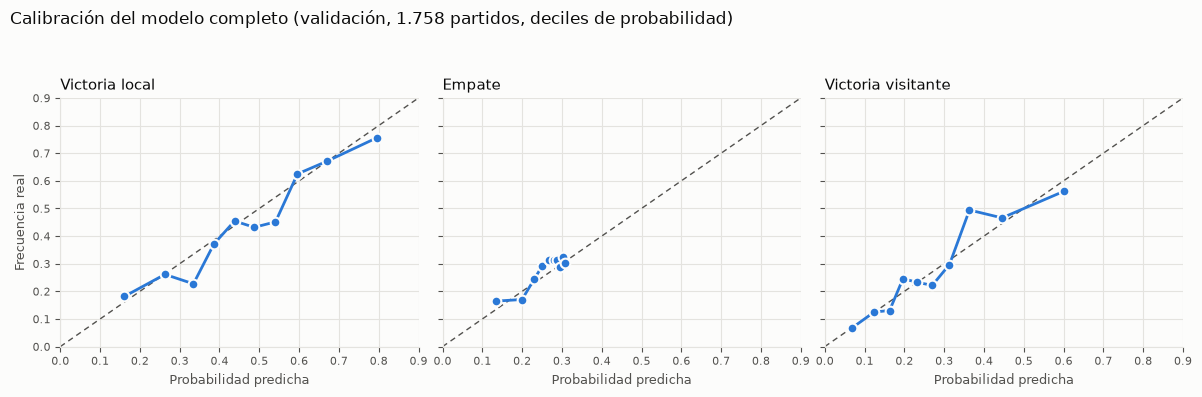

In [18]:
prob_comp = pd.concat(predicciones["Completo"]).sort_index().to_numpy()
y_valid = datos.loc[pd.concat(predicciones["Completo"]).sort_index().index, "y"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor=FONDO, sharey=True)
for ax, (clase, nombre) in zip(axes, ((2, "Victoria local"), (1, "Empate"), (0, "Victoria visitante"))):
    df = pd.DataFrame({"p": prob_comp[:, clase], "real": (y_valid == clase).astype(float)})
    df["grupo"] = pd.qcut(df.p, 10, duplicates="drop")
    g = df.groupby("grupo", observed=True).agg(p=("p", "mean"), real=("real", "mean"), n=("real", "size"))
    ax.plot([0, 1], [0, 1], color=TINTA_2, linewidth=1, linestyle=(0, (4, 3)))
    ax.plot(g.p, g.real, color=SERIE, linewidth=2, marker="o", markersize=7, markeredgecolor=FONDO, markeredgewidth=1.5)
    ax.set_title(nombre, loc="left", fontsize=11, color=TINTA)
    ax.set_xlim(0, 0.9); ax.set_ylim(0, 0.9)
    ax.set_xlabel("Probabilidad predicha", color=TINTA_2, fontsize=9)
    ax.set_facecolor(FONDO)
    ax.grid(color=REJILLA, linewidth=0.8)
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(REJILLA)
axes[0].set_ylabel("Frecuencia real", color=TINTA_2, fontsize=9)
fig.suptitle("Calibración del modelo completo (validación, 1.758 partidos, deciles de probabilidad)",
             x=0.01, ha="left", fontsize=12, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / "04_calibracion.png", dpi=150, facecolor=FONDO)
plt.show()

## Conclusiones de la validación (antes de mirar el test)

**1. La fuerza domina.** El Elo reduce el RPS en 0,028 respecto a las frecuencias históricas, con un IC 95 % muy lejos de 0 y mejora en los 5 pliegues. Quitarlo del modelo completo es, con diferencia, lo que más empeora.

**2. La forma aporta poco y no se distingue del ruido.** Añadir la forma en xG mejora en 4 de 5 pliegues (+0,0009), pero el intervalo incluye el 0. La forma en puntos aporta todavía menos. Coherente con la fase 2: el Elo ya recoge casi todo lo que la forma sabe.

**Un detalle revelador:** con la forma en xG y el Elo en el modelo, el coeficiente de la **forma en puntos es negativo** (−0,11 de media). A igualdad de fuerza y de juego reciente, un equipo que ha sumado *más* puntos de los que su xG justificaba tiende a rendir *peor* después: esos puntos de más eran suerte, y la suerte no se mantiene.

**3. El estilo no mejora la predicción; el choque de estilos la empeora ligeramente.** Añadir las 12 coordenadas de estilo no mejora (2 de 5 pliegues), y las interacciones de choque empeoran de forma pequeña pero consistente. Quitar el estilo del modelo completo **mejora** el RPS. Con 14 variables más y poca señal, el modelo aprende más ruido que patrón, pese a la regularización. Algún efecto aislado es estable en signo (llegar mucho al área rival favorece al local), pero demasiado pequeño para mejorar la predicción. El estilo describe **cómo** juega un equipo, no **cuánto** gana.

**4. No nos perdemos relaciones no lineales:** el *gradient boosting* con todas las variables es **peor** que la regresión ordinal (IC 95 % de la diferencia por encima de 0).

**5. El azar domina el partido individual.** Partiendo de la incertidumbre de las frecuencias históricas:

| Tramo | % |
|---|---|
| Se sabe antes del partido (fuerza, forma, estilo) | ≈ 12 % |
| Se decide en el juego (las ocasiones que crea cada equipo) | ≈ 15 % |
| Azar (la definición de esas ocasiones y todo lo demás) | ≈ 72 % |

Incluso conociendo el xG del partido, quedaría la mayor parte de la incertidumbre: en un solo partido, **el fútbol es sobre todo azar**; la calidad se impone a lo largo de una temporada.

**6. Calibración:** las probabilidades del modelo son fiables (los puntos siguen la diagonal).

**Modelo más simple con el mejor RPS en validación:** Elo + forma en puntos + forma en xG (RPS 0,1963).

## 12. Prerregistro de la evaluación en test

*Escrito y guardado en Git antes de ejecutar ninguna celda sobre las temporadas de test.*

**Datos de test:** 2024/25 y 2025/26, con las mismas reglas de exclusión que en validación.

**Entrenamiento del modelo final:** todas las temporadas de 2014/15 a 2023/24, con el mismo procedimiento que en validación (coordenadas de estilo y regularización ajustadas solo con esas temporadas; la regularización se elige con 2023/24 como validación interna).

**Conclusión principal (única comparación decisiva):**
- **Modelo elegido:** regresión ordinal con **Elo + forma en puntos + forma en xG**, fijado por su RPS en validación.
- Se compara con **solo Elo** mediante la diferencia de RPS partido a partido y su IC 95 % por *bootstrap* emparejado.
- Si el IC excluye el 0 a favor del elegido → la forma aporta sobre la fuerza. Si no → no hay evidencia de que la forma aporte, y se informará así.

**Se informará además, sin que cambie el modelo elegido:**
- Referencias 0 (uniforme), 1 (frecuencias históricas) y "siempre gana el local" (acierto).
- El modelo completo (con estilo y choque de estilos), para comprobar si el estilo sigue sin aportar.
- El techo informativo (xG del partido) y la descomposición antes del partido / juego / azar.
- Resultados por temporada de test.

**Compromiso:** el resultado se publica sea el que sea. Si el modelo completo saliera mejor que el elegido en el test, **no se cambiaría la elección**: se informaría como resultado a investigar.

## 13. Evaluación en test

Se ejecuta exactamente lo prerregistrado.

In [19]:
ELEGIDO = FUERZA + FORMA_P + FORMA_XG

test_eval = test[~test.excluido].merge(xg_partido, on="id_partido", how="left").reset_index(drop=True)
entreno_final, test_eval = coordenadas_estilo(datos, test_eval)
y_t = test_eval.y.to_numpy()
print(f"Entrenamiento: {entreno_final.temporada.min()} a {entreno_final.temporada.max()} ({len(entreno_final)} partidos) · "
      f"test: {len(test_eval)} partidos ({len(test) - len(test_eval)} excluidos por las reglas)")

prob_test = {
    "0 · Uniforme": np.full((len(test_eval), 3), 1 / 3),
    "1 · Frecuencias históricas": np.tile(np.bincount(entreno_final.y, minlength=3) / len(entreno_final),
                                          (len(test_eval), 1)),
}
modelos_test = {}
for nombre, variables in (("2 · Solo Elo", FUERZA), ("Elegido · Elo + forma", ELEGIDO),
                          ("Informativo · completo (con estilo)", COMPLETO),
                          ("Techo · xG del partido (no es predicción)", TECHO)):
    modelo, lam = ajustar_ordinal(entreno_final, variables)
    modelos_test[nombre] = (modelo, variables, lam)
    prob_test[nombre] = modelo.predict_proba(test_eval[variables])

rps_test = {n: rps(p, y_t) for n, p in prob_test.items()}
tabla_test = pd.DataFrame({n: evaluar(p, y_t) for n, p in prob_test.items()}).T
tabla_test.loc["Siempre gana el local"] = [np.nan, np.nan, (y_t == 2).mean()]
tabla_test["lambda"] = pd.Series({n: m[2] for n, m in modelos_test.items()})
tabla_test.round(4)

Entrenamiento: 2014-15 a 2023-24 (3442 partidos) · test: 705 partidos (55 excluidos por las reglas)


,RPS,log_loss,acierto,lambda
0 · Uniforme,0.2366,1.0986,0.2823,NaN
1 · Frecuencias históricas,0.2259,1.0573,0.4709,NaN
2 · Solo Elo,0.1986,0.9741,0.5262,0.00
Elegido · Elo + forma,0.1987,0.9751,0.5362,0.00
Informativo · completo (con estilo),0.1973,0.9706,0.5489,0.00
Techo · xG del partido (no es predicción),0.1702,0.8815,0.5972,0.03
Siempre gana el local,NaN,NaN,0.4709,NaN


### Comparación decisiva: elegido frente a solo Elo

In [20]:
def comparar(simple, completo, n=1000):
    diferencia = rps_test[simple] - rps_test[completo]
    remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(n)]
    return diferencia.mean(), np.percentile(remuestras, 2.5), np.percentile(remuestras, 97.5)

filas = []
for simple, completo, etiqueta in (("2 · Solo Elo", "Elegido · Elo + forma", "DECISIVA · forma sobre la fuerza"),
                                   ("1 · Frecuencias históricas", "2 · Solo Elo", "Informativa · fuerza (Elo)"),
                                   ("Elegido · Elo + forma", "Informativo · completo (con estilo)", "Informativa · estilo y choque")):
    media, inf, sup = comparar(simple, completo)
    filas.append({"comparación": etiqueta, "mejora media de RPS": media, "IC 95 % inferior": inf, "IC 95 % superior": sup,
                  "¿supera el ruido?": "sí" if inf > 0 else ("empeora" if sup < 0 else "no")})
comparaciones_test = pd.DataFrame(filas)
comparaciones_test.round(5)

,comparación,mejora media de RPS,IC 95 % inferior,IC 95 % superior,¿supera el ruido?
0,DECISIVA · forma sobre la fuerza,-0.00008,-0.00217,0.00207,no
1,Informativa · fuerza (Elo),0.02731,0.01752,0.03777,sí
2,Informativa · estilo y choque,0.00136,-0.00029,0.00292,no


In [21]:
# Por temporada de test
por_temporada = pd.DataFrame({n: pd.Series(rps_test[n]).groupby(test_eval.temporada).mean()
                              for n in ["1 · Frecuencias históricas", "2 · Solo Elo", "Elegido · Elo + forma",
                                        "Informativo · completo (con estilo)"]}).T
por_temporada["partidos"] = [len(test_eval)] * len(por_temporada)
por_temporada.round(4)

temporada,2024-25,2025-26,partidos
1 · Frecuencias históricas,0.2294,0.2224,705
2 · Solo Elo,0.1973,0.1999,705
Elegido · Elo + forma,0.1987,0.1987,705
Informativo · completo (con estilo),0.1975,0.1972,705


### Descomposición en test: antes del partido, en el juego, azar

In [22]:
rps_frec_t = rps_test["1 · Frecuencias históricas"].mean()
rps_eleg_t = rps_test["Elegido · Elo + forma"].mean()
rps_techo_t = rps_test["Techo · xG del partido (no es predicción)"].mean()
descomposicion_test = pd.DataFrame({
    "tramo": ["Se sabe antes del partido", "Se decide en el juego (ocasiones creadas)", "Azar"],
    "RPS": [rps_frec_t - rps_eleg_t, rps_eleg_t - rps_techo_t, rps_techo_t],
})
descomposicion_test["% test"] = 100 * descomposicion_test.RPS / rps_frec_t
descomposicion_test["% validación"] = descomposicion["% de la incertidumbre inicial"].values
descomposicion_test.round(3)

,tramo,RPS,% test,% validación
0,Se sabe antes del partido,0.027,12.052,12.449
1,Se decide en el juego (ocasiones creadas),0.029,12.617,15.120
2,Azar,0.170,75.332,72.431


In [23]:
# Coeficientes del modelo elegido (variables estandarizadas; positivo = favorece al local)
modelo_elegido = modelos_test["Elegido · Elo + forma"][0]
pd.Series(modelo_elegido.beta, index=ELEGIDO).round(3).to_frame("coeficiente")

,coeficiente
elo_dif,0.868
forma_puntos_dif,-0.175
forma_xg_dif_dif,0.243


## 14. Resumen visual

Las diferencias de RPS entre modelos son pequeñas frente a su valor (~0,20), así que un gráfico de barras del RPS desde 0 no las mostraría. Mostramos la **mejora respecto a las frecuencias históricas** (cuánto reduce cada modelo la incertidumbre), con su IC 95 %, que sí parte de 0.

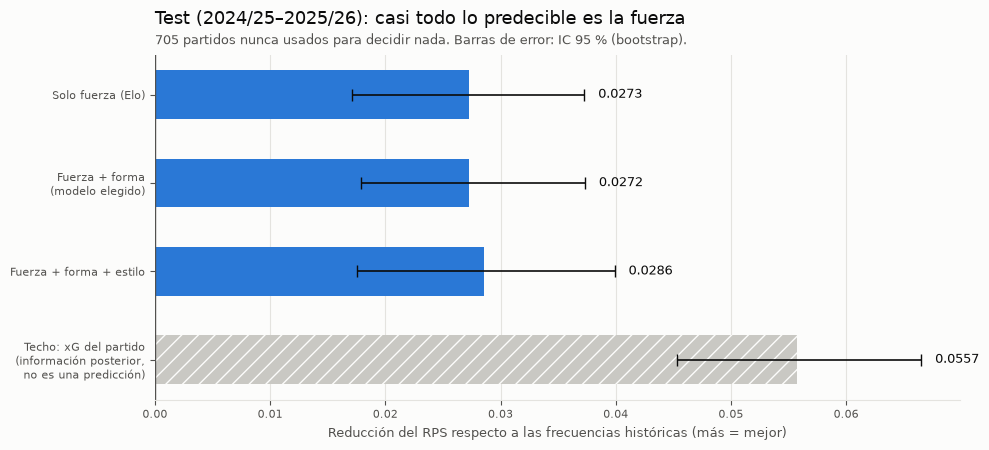

In [24]:
MODELOS_GRAFICO = ["2 · Solo Elo", "Elegido · Elo + forma", "Informativo · completo (con estilo)",
                   "Techo · xG del partido (no es predicción)"]
ETIQUETAS = ["Solo fuerza (Elo)", "Fuerza + forma\n(modelo elegido)", "Fuerza + forma + estilo",
             "Techo: xG del partido\n(información posterior,\nno es una predicción)"]
mejoras = [comparar("1 · Frecuencias históricas", m) for m in MODELOS_GRAFICO]

fig, ax = plt.subplots(figsize=(10, 4.6), facecolor=FONDO)
y = np.arange(len(MODELOS_GRAFICO))[::-1]
for i, ((media, inf, sup), etiqueta) in enumerate(zip(mejoras, ETIQUETAS)):
    techo = i == len(MODELOS_GRAFICO) - 1
    ax.barh(y[i], media, height=0.55, color="#c9c8c3" if techo else SERIE,
            hatch="//" if techo else None, edgecolor=FONDO, linewidth=0)
    ax.errorbar(media, y[i], xerr=[[media - inf], [sup - media]], color=TINTA, capsize=4, linewidth=1.2)
    ax.text(sup + 0.0012, y[i], f"{media:.4f}", va="center", fontsize=9, color=TINTA)
ax.set_yticks(y, ETIQUETAS, fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_2, linewidth=1)
ax.set_xlabel("Reducción del RPS respecto a las frecuencias históricas (más = mejor)", color=TINTA_2, fontsize=9)
ax.set_facecolor(FONDO)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=8)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("Test (2024/25–2025/26): casi todo lo predecible es la fuerza", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.03, f"{len(test_eval)} partidos nunca usados para decidir nada. Barras de error: IC 95 % (bootstrap).",
        transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "04_modelos_test.png", dpi=150, facecolor=FONDO)
plt.show()

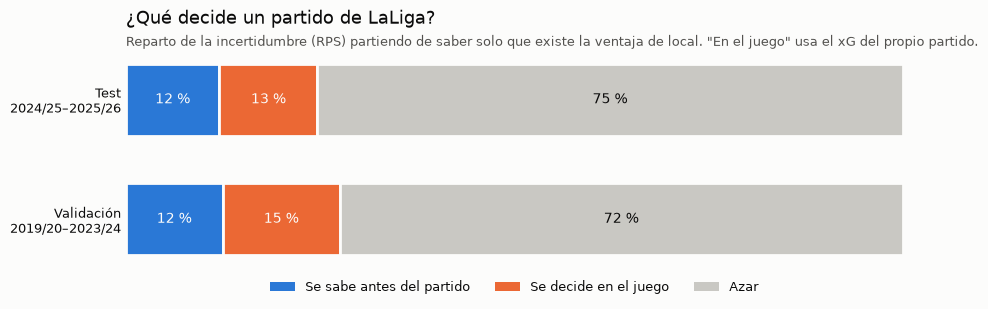

In [25]:
TRAMOS = ["Se sabe antes del partido", "Se decide en el juego", "Azar"]
COLORES_TRAMO = [SERIE, "#eb6834", "#c9c8c3"]
porcentajes = {"Test\n2024/25–2025/26": descomposicion_test["% test"].to_numpy(),
               "Validación\n2019/20–2023/24": descomposicion_test["% validación"].to_numpy()}

fig, ax = plt.subplots(figsize=(10, 3.2), facecolor=FONDO)
for fila, (nombre, valores) in enumerate(porcentajes.items()):
    izquierda = 0
    for tramo, valor, color in zip(TRAMOS, valores, COLORES_TRAMO):
        ax.barh(fila, valor, left=izquierda, height=0.6, color=color, edgecolor=FONDO, linewidth=2)
        ax.text(izquierda + valor / 2, fila, f"{valor:.0f} %", ha="center", va="center", fontsize=10,
                color=FONDO if color != "#c9c8c3" else TINTA)
        izquierda += valor
ax.set_yticks(range(len(porcentajes)), list(porcentajes), fontsize=9, color=TINTA)
ax.invert_yaxis()
ax.tick_params(length=0)
ax.set_xlim(0, 100)
ax.set_xticks([])
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_facecolor(FONDO)
for tramo, color in zip(TRAMOS, COLORES_TRAMO):
    ax.barh(np.nan, 0, color=color, label=tramo)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=9, labelcolor=TINTA)
ax.set_title("¿Qué decide un partido de LaLiga?", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.04, "Reparto de la incertidumbre (RPS) partiendo de saber solo que existe la ventaja de local. "
        "\"En el juego\" usa el xG del propio partido.", transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "04_que_decide_un_partido.png", dpi=150, facecolor=FONDO)
plt.show()

## 15. Conclusiones: ¿qué decide un partido de LaLiga?

**Resultado de la comparación prerregistrada:** el modelo elegido (Elo + forma) **no mejora** a solo Elo en test: diferencia de RPS −0,0001, IC 95 % de −0,0022 a +0,0021. **No hay evidencia de que la forma aporte sobre la fuerza.** En validación mejoraba algo (+0,001) sin superar el ruido; en test ni eso.

**Lo que se confirma en datos nunca vistos:**

1. **La fuerza (Elo) es casi todo lo predecible.** Reduce el RPS en 0,027 (IC 0,018–0,038), en línea con la validación. Acierto: 52,6 % frente al 47,1 % de "siempre gana el local".
2. **La forma no añade información sobre la fuerza.** El Elo, al actualizarse partido a partido, ya incorpora el momento del equipo. Con un matiz interesante que se mantiene en test: con la forma en xG en el modelo, la forma en puntos tiene coeficiente **negativo**. Los puntos "de más" respecto al juego son suerte que no se mantiene.
3. **El estilo tampoco aporta de forma fiable.** En test el modelo completo sale ligeramente mejor (+0,0014), pero el IC incluye el 0 y en validación era peor. Cumpliendo el prerregistro, no cambia el modelo elegido: se registra como resultado no concluyente.
4. **El azar domina el partido individual.** El reparto se repite en test: ≈ **12 %** se sabe antes del partido, ≈ **13 %** se decide en el juego (las ocasiones que crea cada equipo) y ≈ **75 %** es azar (la definición de esas ocasiones y todo lo demás).

**Respuesta a la pregunta central:** de lo que se puede saber antes de un partido, lo que importa es **la fuerza** de los equipos; ni el momento de forma ni el estilo de juego añaden información fiable. Pero lo previsible es la parte pequeña: **la mayor parte de un partido concreto la decide el azar**, y la calidad solo se impone con la acumulación de partidos a lo largo de una temporada.

**Limitaciones:**
- Sin cuotas de apuestas no hay comparación con el mercado; el listón son los modelos de referencia.
- El estilo se mide sin posesión (no está en las fuentes) y con variables cuya fiabilidad es moderada.
- Parámetros del Elo fijados a priori (H = 65 sin fuente citable; la regla de ascendidos los infravalora).
- El "techo" usa el xG de Understat, que es a su vez un modelo: el reparto juego/azar depende de lo bueno que sea ese xG.

## 16. Exportación para Power BI

El informe final (fase 6) se construye en Power BI a partir de estas tablas. Criterio de reparto: **lo que se agrega (medias, recuentos, calibración) se calcula en Power BI** a partir de los datos por partido; **lo inferencial (intervalos por *bootstrap*) se exporta tal como se calculó aquí**, porque no se puede reproducir fielmente en DAX.

| Fichero | Contenido | ¿En Git? |
|---|---|---|
| `modelo_predicciones.csv` | Probabilidades de cada partido por modelo, **solo fuera de muestra**: validación progresiva (2019/20–2023/24) y test (2024/25–2025/26) | No (usa la forma en xG, derivada de Understat) |
| `modelo_metricas.csv` | RPS, log-loss y acierto por modelo, conjunto y temporada. Sirve para **cuadrar** las medidas DAX con el notebook | Sí |
| `modelo_comparaciones.csv` | Mejoras de RPS con su IC 95 % (*bootstrap* emparejado), en validación y en test | Sí |
| `modelo_descomposicion.csv` | Reparto de la incertidumbre: antes del partido / en el juego / azar | Sí |

⚠️ No se exporta ninguna probabilidad *dentro de muestra*: cada predicción de validación viene de un modelo que no vio esa temporada, y las de test de un modelo entrenado solo hasta 2023/24.

In [26]:
def documentar(fichero, df, descripciones, fuente, disponible_desde, momento):
    """Sustituye en el diccionario de datos las filas de `fichero` por las de sus columnas actuales."""
    assert list(descripciones) == list(df.columns), f"{fichero}: columnas sin documentar o en otro orden"
    ruta = PROCESSED / "diccionario_datos.csv"
    diccionario = pd.read_csv(ruta)
    nuevas = pd.DataFrame([{"fichero": fichero, "columna": c, "tipo": str(df[c].dtype), "descripcion": d,
                            "fuente": fuente, "disponible_desde": disponible_desde,
                            "momento": momento(c) if callable(momento) else momento}
                           for c, d in descripciones.items()])
    pd.concat([diccionario[diccionario.fichero != fichero], nuevas]).to_csv(ruta, index=False, encoding="utf-8")

In [27]:
A_RESULTADO = np.array(["2", "X", "1"])          # y: 0 visitante, 1 empate, 2 local
# nombre común → (variables, clave en la validación de la sección 8, clave en el test de la sección 13)
MODELOS_EXPORT = {
    "Frecuencias históricas": (None, "Frecuencias históricas", "1 · Frecuencias históricas"),
    "Solo Elo": (FUERZA, "Elo", "2 · Solo Elo"),
    "Elo + forma (elegido)": (ELEGIDO, "+ forma (xG)", "Elegido · Elo + forma"),
    "Completo con estilo (informativo)": (COMPLETO, "+ choque (completo)", "Informativo · completo (con estilo)"),
}


def filas_prediccion(df, prob, modelo, conjunto):
    y = df.y.to_numpy()
    return pd.DataFrame({
        "id_partido": df.id_partido.to_numpy(), "temporada": df.temporada.to_numpy(),
        "conjunto": conjunto, "modelo": modelo,
        "p_local": prob[:, 2], "p_empate": prob[:, 1], "p_visitante": prob[:, 0],
        "resultado": A_RESULTADO[y], "prediccion": A_RESULTADO[prob.argmax(1)], "acierto": prob.argmax(1) == y,
        "rps": rps(prob, y), "log_loss": log_loss(prob, y)})


# En la sección 8 solo se guardó el RPS de cada partido; se vuelven a ajustar los mismos modelos para tener las probabilidades
bloques = []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    for nombre, (variables, clave_valid, _) in MODELOS_EXPORT.items():
        if variables is None:
            prob = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
        else:
            prob = ajustar_ordinal(entreno, variables)[0].predict_proba(valid[variables])
        assert np.allclose(rps(prob, valid.y.to_numpy()), rps_partido[clave_valid].loc[valid.index]), nombre
        bloques.append(filas_prediccion(valid, prob, nombre, "validación"))
for nombre, (_, _, clave_test) in MODELOS_EXPORT.items():
    bloques.append(filas_prediccion(test_eval, prob_test[clave_test], nombre, "test"))

modelo_predicciones = pd.concat(bloques, ignore_index=True)
assert not modelo_predicciones.duplicated(["id_partido", "modelo"]).any()
assert np.allclose(modelo_predicciones[["p_local", "p_empate", "p_visitante"]].sum(axis=1), 1)
modelo_predicciones.groupby(["conjunto", "modelo"]).agg(partidos=("rps", "size"), RPS=("rps", "mean"),
                                                         acierto=("acierto", "mean")).round(4)

partidos     RPS  acierto
conjunto   modelo                                                      
test       Completo con estilo (informativo)       705  0.1973   0.5489
           Elo + forma (elegido)                   705  0.1987   0.5362
           Frecuencias históricas                  705  0.2259   0.4709
           Solo Elo                                705  0.1986   0.5262
validación Completo con estilo (informativo)      1758  0.1974   0.5250
           Elo + forma (elegido)                  1758  0.1963   0.5216
           Frecuencias históricas                 1758  0.2255   0.4431
           Solo Elo                               1758  0.1974   0.5188

In [28]:
# Tabla de control: las medidas DAX del informe deben dar exactamente estas cifras
metricas = (modelo_predicciones.groupby(["conjunto", "modelo", "temporada"])
            .agg(partidos=("rps", "size"), rps=("rps", "mean"), log_loss=("log_loss", "mean"), acierto=("acierto", "mean"))
            .reset_index())
total = (modelo_predicciones.groupby(["conjunto", "modelo"])
         .agg(partidos=("rps", "size"), rps=("rps", "mean"), log_loss=("log_loss", "mean"), acierto=("acierto", "mean"))
         .reset_index().assign(temporada="Todas"))
siempre_local = (modelo_predicciones[modelo_predicciones.modelo == "Solo Elo"]
                 .assign(local=lambda d: d.resultado == "1")
                 .groupby(["conjunto", "temporada"]).agg(partidos=("local", "size"), acierto=("local", "mean")).reset_index())
siempre_local = pd.concat([siempre_local, siempre_local.groupby("conjunto").apply(
    lambda d: pd.Series({"temporada": "Todas", "partidos": d.partidos.sum(),
                         "acierto": np.average(d.acierto, weights=d.partidos)}), include_groups=False).reset_index()])
modelo_metricas = pd.concat([metricas, total, siempre_local.assign(modelo="Siempre gana el local")], ignore_index=True)[
    ["conjunto", "modelo", "temporada", "partidos", "rps", "log_loss", "acierto"]]

# Deben coincidir con las cifras publicadas (sección 13 y README)
control = modelo_metricas.set_index(["conjunto", "modelo", "temporada"])
assert np.isclose(control.loc[("test", "Solo Elo", "Todas"), "rps"], tabla_test.loc["2 · Solo Elo", "RPS"])
assert np.isclose(control.loc[("test", "Elo + forma (elegido)", "Todas"), "rps"], tabla_test.loc["Elegido · Elo + forma", "RPS"])
assert np.isclose(control.loc[("test", "Siempre gana el local", "Todas"), "acierto"], tabla_test.loc["Siempre gana el local", "acierto"])
modelo_metricas[modelo_metricas.temporada == "Todas"].round(4)

,conjunto,modelo,temporada,partidos,rps,log_loss,acierto
28,test,Completo con estilo (informativo),Todas,705,0.1973,0.9706,0.5489
29,test,Elo + forma (elegido),Todas,705,0.1987,0.9751,0.5362
30,test,Frecuencias históricas,Todas,705,0.2259,1.0573,0.4709
31,test,Solo Elo,Todas,705,0.1986,0.9741,0.5262
32,validación,Completo con estilo (informativo),Todas,1758,0.1974,0.9908,0.5250
33,validación,Elo + forma (elegido),Todas,1758,0.1963,0.9867,0.5216
34,validación,Frecuencias históricas,Todas,1758,0.2255,1.0746,0.4431
35,validación,Solo Elo,Todas,1758,0.1974,0.9912,0.5188
43,test,Siempre gana el local,Todas,705,NaN,NaN,0.4709
44,validación,Siempre gana el local,Todas,1758,NaN,NaN,0.4431


In [29]:
def a_filas(df, conjunto):
    return pd.DataFrame({
        "conjunto": conjunto, "comparacion": df["comparación"], "mejora_rps": df["mejora media de RPS"],
        "ic95_inferior": df["IC 95 % inferior"], "ic95_superior": df["IC 95 % superior"],
        "supera_ruido": df["¿supera el ruido?"],
        "pliegues_en_los_que_mejora": df.get("pliegues en los que mejora", pd.Series(pd.NA, index=df.index))})


# mejoras sobre frecuencias históricas en test (las del gráfico de la sección 14)
NOMBRE_COMUN = {clave_test: nombre for nombre, (_, _, clave_test) in MODELOS_EXPORT.items()}
NOMBRE_COMUN["Techo · xG del partido (no es predicción)"] = "Techo: xG del partido (no es predicción)"
sobre_frecuencias = pd.DataFrame([{"comparación": f"Sobre frecuencias: {NOMBRE_COMUN[m]}", "mejora media de RPS": media,
                                   "IC 95 % inferior": inf, "IC 95 % superior": sup}
                                  for m, (media, inf, sup) in zip(MODELOS_GRAFICO, mejoras)])
sobre_frecuencias["¿supera el ruido?"] = np.where(sobre_frecuencias["IC 95 % inferior"] > 0, "sí",
                                                  np.where(sobre_frecuencias["IC 95 % superior"] < 0, "empeora", "no"))

modelo_comparaciones = pd.concat([a_filas(significacion, "validación"), a_filas(comparaciones_test, "test"),
                                  a_filas(sobre_frecuencias, "test")], ignore_index=True)

modelo_descomposicion = pd.concat([
    pd.DataFrame({"conjunto": "validación", "orden": [1, 2, 3], "tramo": descomposicion_test.tramo,
                  "modelo_antes_del_partido": "Completo con estilo (informativo)",
                  "rps": descomposicion.RPS.to_numpy(), "porcentaje": descomposicion["% de la incertidumbre inicial"].to_numpy()}),
    pd.DataFrame({"conjunto": "test", "orden": [1, 2, 3], "tramo": descomposicion_test.tramo,
                  "modelo_antes_del_partido": "Elo + forma (elegido)",
                  "rps": descomposicion_test.RPS.to_numpy(), "porcentaje": descomposicion_test["% test"].to_numpy()}),
], ignore_index=True)
assert np.allclose(modelo_descomposicion.groupby("conjunto").porcentaje.sum(), 100)
modelo_comparaciones.round(4)

,conjunto,comparacion,mejora_rps,ic95_inferior,ic95_superior,supera_ruido,pliegues_en_los_que_mejora
0,validación,Añadir: fuerza (Elo),0.0281,0.0223,0.0337,sí,5 de 5
1,validación,Añadir: forma en puntos,0.0003,-0.0004,0.0008,no,4 de 5
2,validación,Añadir: forma en xG,0.0009,-0.0005,0.0022,no,4 de 5
3,validación,Añadir: estilo,-0.0006,-0.0016,0.0005,no,2 de 5
4,validación,Añadir: choque de estilos,-0.0005,-0.0009,-0.0001,empeora,2 de 5
5,validación,Quitar: fuerza,0.0147,0.0106,0.0185,sí,5 de 5
6,validación,Quitar: forma,0.0005,-0.0008,0.0018,no,3 de 5
7,validación,Quitar: estilo y choque,-0.0011,-0.0022,-0.0000,empeora,0 de 5
8,validación,Quitar: choque,-0.0005,-0.0009,-0.0001,empeora,2 de 5
9,test,DECISIVA · forma sobre la fuerza,-0.0001,-0.0022,0.0021,no,<NA>


In [30]:
MOMENTO_PRED = "probabilidad calculada antes del partido, fuera de muestra (resultado, acierto, rps y log_loss se conocen después)"
DESC_PREDICCIONES = {
    "id_partido": "Identificador del partido (enlaza con partidos.csv)",
    "temporada": "Temporada",
    "conjunto": "validación (2019/20–2023/24, cada temporada predicha con las anteriores) o test (2024/25–2025/26, modelo entrenado hasta 2023/24)",
    "modelo": "Frecuencias históricas / Solo Elo / Elo + forma (elegido) / Completo con estilo (informativo)",
    "p_local": "Probabilidad de victoria local", "p_empate": "Probabilidad de empate",
    "p_visitante": "Probabilidad de victoria visitante",
    "resultado": "Resultado real: 1 local, X empate, 2 visitante",
    "prediccion": "Resultado más probable según el modelo (1, X o 2)",
    "acierto": "True si el resultado más probable es el que ocurrió",
    "rps": "Ranked Probability Score del partido (0 perfecto; menor es mejor)",
    "log_loss": "Log-loss del partido (−log de la probabilidad del resultado real)",
}
DESC_METRICAS = {
    "conjunto": "validación o test", "modelo": "Modelo (incluye «Siempre gana el local», que solo tiene acierto)",
    "temporada": "Temporada, o «Todas» para el conjunto completo", "partidos": "Partidos evaluados",
    "rps": "RPS medio", "log_loss": "Log-loss medio", "acierto": "Proporción de aciertos",
}
DESC_COMPARACIONES = {
    "conjunto": "validación o test", "comparacion": "Qué se compara (añadir o quitar un bloque, o mejora sobre frecuencias)",
    "mejora_rps": "Reducción media del RPS (positivo = el modelo más completo es mejor)",
    "ic95_inferior": "Límite inferior del IC 95 % (bootstrap emparejado por partido, 1.000 remuestras)",
    "ic95_superior": "Límite superior del IC 95 %",
    "supera_ruido": "sí (IC por encima de 0) / no (incluye el 0) / empeora (IC por debajo de 0)",
    "pliegues_en_los_que_mejora": "Temporadas de validación en las que mejora (solo validación)",
}
DESC_DESCOMPOSICION = {
    "conjunto": "validación o test", "orden": "Orden del tramo (para ordenar el gráfico)",
    "tramo": "Se sabe antes del partido / se decide en el juego (ocasiones creadas) / azar",
    "modelo_antes_del_partido": "Modelo usado como «lo que se sabe antes del partido»",
    "rps": "RPS atribuido al tramo", "porcentaje": "% de la incertidumbre inicial (RPS de frecuencias históricas)",
}

for fichero, df, desc in (("modelo_predicciones.csv", modelo_predicciones, DESC_PREDICCIONES),
                          ("modelo_metricas.csv", modelo_metricas, DESC_METRICAS),
                          ("modelo_comparaciones.csv", modelo_comparaciones, DESC_COMPARACIONES),
                          ("modelo_descomposicion.csv", modelo_descomposicion, DESC_DESCOMPOSICION)):
    df.to_csv(PROCESSED / fichero, index=False, encoding="utf-8")
    documentar(fichero, df, desc, "Calculado (modelo de la fase 4)", "2019-20",
               MOMENTO_PRED if fichero == "modelo_predicciones.csv" else "resultado de la evaluación (después de los partidos)")
    print(f"{fichero}: {len(df)} filas")

modelo_predicciones.csv: 9852 filas
modelo_metricas.csv: 45 filas
modelo_comparaciones.csv: 16 filas
modelo_descomposicion.csv: 6 filas
